In [19]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sns.set_style('whitegrid')
plt.rcParams["figure.figsize"] = (7,5)
NAVY = "#004BA0"
GOLD = "#D1AB3E"

In [20]:
df = pd.read_csv("IPLPlayerStat.csv")
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [21]:
df = df.drop(columns=['Unnamed: 0'])

In [22]:
print("Shape : ", df.shape)
df.head()

Shape :  (605, 16)


,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [23]:
df['balls_faced'].describe()

count     605.000000
mean      373.477686
std       764.432561
min         1.000000
25%        18.000000
50%        73.000000
75%       285.000000
max      5266.000000
Name: balls_faced, dtype: float64

In [24]:
print(df.isnull().sum())

player                 0
runs                   0
boundaries             0
balls_faced            0
wickets                0
balls_bowled           0
runs_conceded          0
matches                0
batting_avg            0
batting_strike_rate    0
boundaries_percent     0
bowling_economy        0
bowling_avg            0
bowling_strike_rate    0
catches                0
stumpings              0
dtype: int64


In [27]:
X = df[["balls_faced"]]
y = df['runs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

print("Intercept : ", round(model.intercept_, 2))
print("Slop : ", round(model.coef_[0], 4))
print(f"\nMeaning : every extra ball faced adds `{model.coef_[0]:.2f} runs on average . ")

Intercept :  -15.33
Slop :  1.2844

Meaning : every extra ball faced adds `1.28 runs on average . 


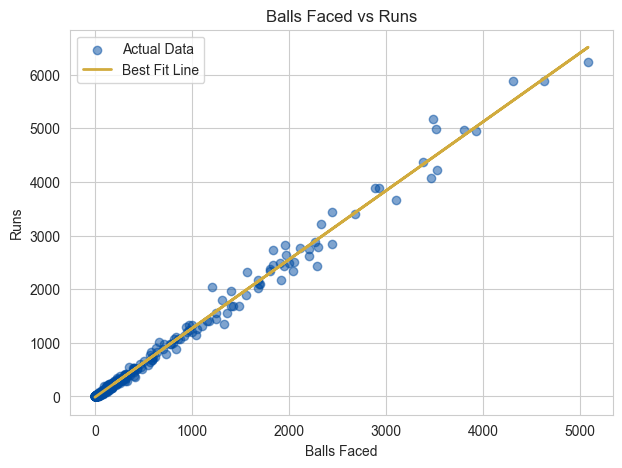

In [32]:
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, color=NAVY, alpha=0.5, label= "Actual Data")
plt.plot(X_train, model.predict(X_train), color=GOLD, linewidth=2, label="Best Fit Line")
# plt.plot(X_train, y_train, color=GOLD, linewidth=2, label="Regression Line")
plt.xlabel("Balls Faced")
plt.ylabel("Runs")
plt.title("Balls Faced vs Runs")
plt.legend()

In [33]:
y_pred = model.predict(X_test)

comparision = pd.DataFrame({
    "balls_faced" : X_test["balls_faced"].values,
    "acutal_runs" : y_test.values,
    "predicted_runs" : np.round(y_pred,1)
})

comparision.head()

,balls_faced,acutal_runs,predicted_runs
0,434,522,542.1
1,27,40,19.3
2,57,76,57.9
3,31,21,24.5
4,552,663,693.6


In [36]:
new_players = pd.DataFrame({"balls_faced" : [100,300,600]})
new_preds = model.predict(new_players)

for balls,runs in zip(new_players["balls_faced"], new_preds):
    print(f"Ball Faced = {balls} -> predicted runs = {runs:.0f}")

Ball Faced = 100 -> predicted runs = 113
Ball Faced = 300 -> predicted runs = 370
Ball Faced = 600 -> predicted runs = 755
